In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from utils import load_dataset

plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 15,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
})

GRAPH_DIR = Path('exploration/figures')
GRAPH_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
benchmarks = ['SEASON', 'DRIFT', 'PERIODIC_SPACES', 'RANDOM', 'WORKERS']
frames = []
for b in benchmarks:
    df_b = pd.read_csv(f'selected_ids/hourly/{b}.csv')
    df_b['benchmark'] = b
    frames.append(df_b)
selected = pd.concat(frames, ignore_index=True)
print(f'Total selected series: {len(selected)}')
selected.groupby('benchmark').size()

Total selected series: 263


benchmark
DRIFT              75
PERIODIC_SPACES    25
RANDOM             63
SEASON             75
WORKERS            25
dtype: int64

In [3]:
level_map = {'Institutions': 'institutions', 'Subnets': 'subnets', 'IPs': 'ips_full'}

data_by_level = {}
for level in selected['level'].unique():
    ids = selected.loc[selected['level'] == level, 'ts_id'].unique().tolist()
    data_by_level[level] = load_dataset(level_map[level], ts_ids=ids)

100%|█| 58/58 [00:0


Config Details
    Used for database: CESNET-TimeSeries24
    Aggregation: AgreggationType.AGG_1_HOUR
    Source: SourceType.INSTITUTIONS

    Time series
        Time series IDS: [15 16 38 39 52 ... 272 277 279 280 281], Length=58
    Time periods
        Train time periods: range(0, 6718)
        Val time periods: None
        Test time periods: None
        All time periods: range(0, 6718)
    Features
        Taken features: ['n_bytes']
        Default values: [0.]
        Time series ID included: True
        Time included: True    
        Time format: TimeFormat.DATETIME
    Sliding window
        Sliding window size: None
        Sliding window prediction size: None
        Sliding window step size: 1
        Set shared size: 0
    Fillers
        Filler type: NoFiller
    Transformers
        Transformer type: NoTransformer
    Anomaly handler
        Anomaly handler type: NoAnomalyHandler        
    Batch sizes
        Train batch size: 32
        Val batch size: 64
       

institutions (AGG_1_HOUR): 58 series loaded


100%|█| 72/72 [00:0


Config Details
    Used for database: CESNET-TimeSeries24
    Aggregation: AgreggationType.AGG_1_HOUR
    Source: SourceType.INSTITUTION_SUBNETS

    Time series
        Time series IDS: [ 91 133 136 145 146 ... 522 532 535 537 542], Length=72
    Time periods
        Train time periods: range(0, 6718)
        Val time periods: None
        Test time periods: None
        All time periods: range(0, 6718)
    Features
        Taken features: ['n_bytes']
        Default values: [0.]
        Time series ID included: True
        Time included: True    
        Time format: TimeFormat.DATETIME
    Sliding window
        Sliding window size: None
        Sliding window prediction size: None
        Sliding window step size: 1
        Set shared size: 0
    Fillers
        Filler type: NoFiller
    Transformers
        Transformer type: NoTransformer
    Anomaly handler
        Anomaly handler type: NoAnomalyHandler        
    Batch sizes
        Train batch size: 32
        Val batch size

subnets (AGG_1_HOUR): 72 series loaded


100%|█| 123/123 [00


Config Details
    Used for database: CESNET-TimeSeries24
    Aggregation: AgreggationType.AGG_1_HOUR
    Source: SourceType.IP_ADDRESSES_FULL

    Time series
        Time series IDS: [1370 1749 1784 3313 6005 ... 591569 598086 733725 754726 790615], Length=123
    Time periods
        Train time periods: range(0, 6718)
        Val time periods: None
        Test time periods: None
        All time periods: range(0, 6718)
    Features
        Taken features: ['n_bytes']
        Default values: [0.]
        Time series ID included: True
        Time included: True    
        Time format: TimeFormat.DATETIME
    Sliding window
        Sliding window size: None
        Sliding window prediction size: None
        Sliding window step size: 1
        Set shared size: 0
    Fillers
        Filler type: NoFiller
    Transformers
        Transformer type: NoTransformer
    Anomaly handler
        Anomaly handler type: NoAnomalyHandler        
    Batch sizes
        Train batch size: 32
   

ips_full (AGG_1_HOUR): 123 series loaded


In [ ]:
def plot_series(benchmark, level, ts_id, save=False):
    """Plot a single time series and optionally save to bench_graphs/."""
    d = data_by_level[level]
    grp = d['df'][d['df'][d['id_col']] == ts_id].reset_index(drop=True)
    t, y = grp['datetime'], grp['n_bytes'].values

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(t, y, linewidth=0.6, color='#1f77b4')
    ax.set_title(f'{level} | ID = {ts_id}')
    ax.set_xlabel('Time')
    ax.set_ylabel('n_bytes')
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    fig.autofmt_xdate()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    if save:
        fname = GRAPH_DIR / f'{benchmark}_{level}_{ts_id}.pdf'
        fig.savefig(fname, bbox_inches='tight')
        print(f'Saved: {fname}')

    plt.show()
    return None

## Usage

Call `plot_series(benchmark, level, ts_id, save=True)` to plot and export to PDF.

Examples:

In [56]:
def plot_forecast_setup(context_ratio=0.6, save=False, save_path=None):
    from matplotlib.patches import Rectangle

    np.random.seed(42)
    n = 500
    x = np.linspace(0, 10, n)
    y = (np.sin(x * 2.5) + 0.4 * np.sin(x * 5.8) + 0.2 * np.sin(x * 12.5)
         + 0.15 * np.cumsum(np.random.randn(n)) / np.sqrt(n))
    y = (y - y.min()) / (y.max() - y.min()) * 0.7 + 0.15

    step = max(1, n // 40)
    marker_idx = np.arange(0, n, step)
    marker_x = x[marker_idx]
    n_markers = len(marker_idx)

    margin_markers = 3
    l_start_mi = margin_markers
    l_end_mi = l_start_mi + int((n_markers - margin_markers) * context_ratio)
    h_end_mi = n_markers - 1

    l_start = marker_idx[l_start_mi]
    l_end = marker_idx[l_end_mi]
    h_end = marker_idx[h_end_mi]

    ymin_data = 0.0
    ymax_data = 1.1

    fig, ax = plt.subplots(figsize=(12, 4))

    ax.add_patch(Rectangle((x[l_start], ymin_data), x[l_end] - x[l_start],
                            ymax_data - ymin_data, alpha=0.12, color='#4a90d9',
                            linewidth=0, zorder=0))
    ax.add_patch(Rectangle((x[l_end], ymin_data), x[h_end] - x[l_end],
                            ymax_data - ymin_data, alpha=0.12, color='#e8a838',
                            linewidth=0, zorder=0))

    ax.plot(x[:l_end + 1], y[:l_end + 1], color='black', linewidth=1.2, zorder=3)
    ax.plot(x[l_end:h_end + 1], y[l_end:h_end + 1], color='black', linewidth=1.2,
            linestyle='--', zorder=3)

    seg_len = h_end + 1 - l_end
    uncertainty = 0.05 * np.linspace(0.2, 1, seg_len)
    ax.fill_between(x[l_end:h_end + 1],
                    y[l_end:h_end + 1] - uncertainty,
                    y[l_end:h_end + 1] + uncertainty,
                    alpha=0.15, color='#e8a838', zorder=2)

    ax.vlines(x[l_end], ymin=ymin_data, ymax=ymax_data, color='black',
              linestyle=':', linewidth=1, zorder=4)

    label_y = ymax_data + 0.08
    ax.text((x[l_start] + x[l_end]) / 2, label_y, 'Context window ($L$)',
            ha='center', va='bottom', fontsize=13, clip_on=False)
    ax.text((x[l_end] + x[h_end]) / 2, label_y, 'Forecast horizon ($H$)',
            ha='center', va='bottom', fontsize=13, clip_on=False)

    arrow_y = -0.08
    nudge = 0.06
    ax.annotate('', xy=(x[l_start] - nudge, arrow_y), xytext=(x[l_end] + nudge, arrow_y),
                arrowprops=dict(arrowstyle='<->', color='#4a90d9', lw=1.5),
                annotation_clip=False)
    ax.text((x[l_start] + x[l_end]) / 2, arrow_y - 0.05, '$L$',
            ha='center', va='top', fontsize=13, color='#4a90d9', clip_on=False)

    ax.annotate('', xy=(x[l_end] - nudge, arrow_y), xytext=(x[h_end] + nudge, arrow_y),
                arrowprops=dict(arrowstyle='<->', color='#c87a1a', lw=1.5),
                annotation_clip=False)
    ax.text((x[l_end] + x[h_end]) / 2, arrow_y - 0.05, '$H$',
            ha='center', va='top', fontsize=13, color='#c87a1a', clip_on=False)

    ax.text(x[l_end], arrow_y - 0.05, '$t$', ha='center', va='top', fontsize=13,
            clip_on=False)

    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])

    ax_origin_x = x[0] - 0.15
    ax.plot([ax_origin_x, ax_origin_x], [ymin_data, ymax_data + 0.12], color='black',
            linewidth=1.2, clip_on=False, zorder=5)
    ax.plot(ax_origin_x, ymax_data + 0.12, marker='^', markersize=7, color='black',
            clip_on=False, zorder=5)
    ax.plot([ax_origin_x, x[-1] + 0.4], [ymin_data, ymin_data], color='black',
            linewidth=1.2, clip_on=False, zorder=5)
    ax.plot(x[-1] + 0.4, ymin_data, marker='>', markersize=7, color='black',
            clip_on=False, zorder=5)

    tick_len = 0.02
    for mx in marker_x:
        ax.plot([mx, mx], [ymin_data, ymin_data - tick_len], color='black',
                linewidth=1.2, clip_on=False, zorder=5)

    ax.set_xlim(ax_origin_x - 0.1, x[-1] + 0.5)
    ax.set_ylim(ymin_data, ymax_data + 0.15)

    ax.text(x[-1] + 0.5, ymin_data, '$T$', ha='left', va='center', fontsize=14,
            clip_on=False)
    ax.text(ax_origin_x, ymax_data + 0.2, '$y$', ha='center', va='bottom', fontsize=14,
            clip_on=False)

    plt.tight_layout()

    if save and save_path:
        fig.savefig(save_path, bbox_inches='tight')
        print(f'Saved: {save_path}')

    plt.show()

In [94]:
from statsmodels.tsa.stattools import acf

def plot_acf_comparison(benchmark, level, ts_id, max_lag=336, save=False):
    d = data_by_level[level]
    grp = d['df'][d['df'][d['id_col']] == ts_id].reset_index(drop=True)
    y = grp['n_bytes'].astype(float).values

    acf_vals = acf(y, nlags=max_lag, fft=True)
    print(np.max(acf_vals[1:]))
    ci = 1.96 / np.sqrt(len(y))

    fig, ax = plt.subplots(figsize=(14, 4))
    lags = np.arange(1, len(acf_vals))
    ax.bar(lags, acf_vals[1:], width=1, alpha=0.7, color='steelblue')
    ax.axhline(ci, color='red', linestyle='--', alpha=0.5, label=f'95% CI ({chr(177)}{ci:.3f})')
    ax.axhline(-ci, color='red', linestyle='--', alpha=0.5)
    # for h in range(12, max_lag + 1, 12):
        # ax.axvline(h, color='gray', linestyle=':', alpha=0.3)
    ax.set_xticks(np.arange(0, max_lag + 1, 24))
    ax.set_xticks(np.arange(0, max_lag + 1, 12), minor=True)
    ax.set_ylabel('$r_k$')
    ax.set_xlabel('Lag (hours)')
    ax.legend()
    ax.grid(axis='both', alpha=0.3)
    plt.tight_layout()

    if save:
        fname = GRAPH_DIR / f'{benchmark}_ACF_usage_{level}_{ts_id}.pdf'
        fig.savefig(fname, bbox_inches='tight')
        print(f'Saved: {fname}')

    plt.show()

0.003491389941912674
Saved: exploration/figures/RANDOM_ACF_usage_Subnets_199.pdf


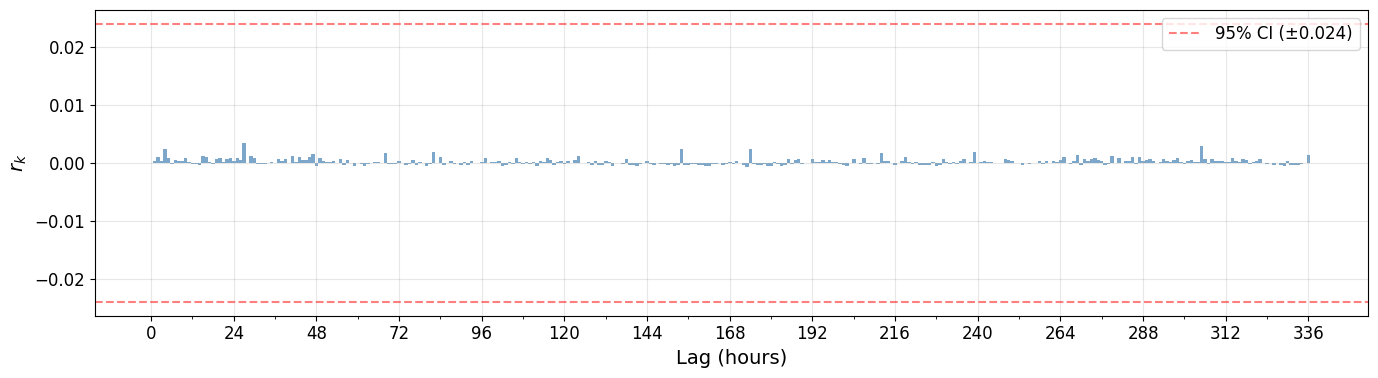

0.35255024642048555
Saved: exploration/figures/SEASON_ACF_usage_Institutions_15.pdf


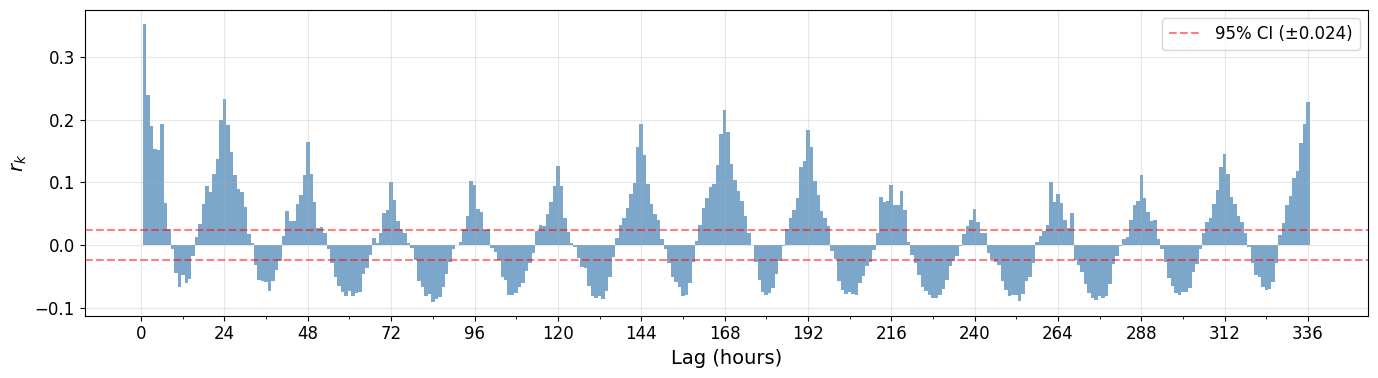

In [96]:
plot_acf_comparison('RANDOM', 'Subnets', 199, save=True)
plot_acf_comparison('SEASON', 'Institutions', 15, save=True)

Saved: exploration/figures/forecast_setup.pdf


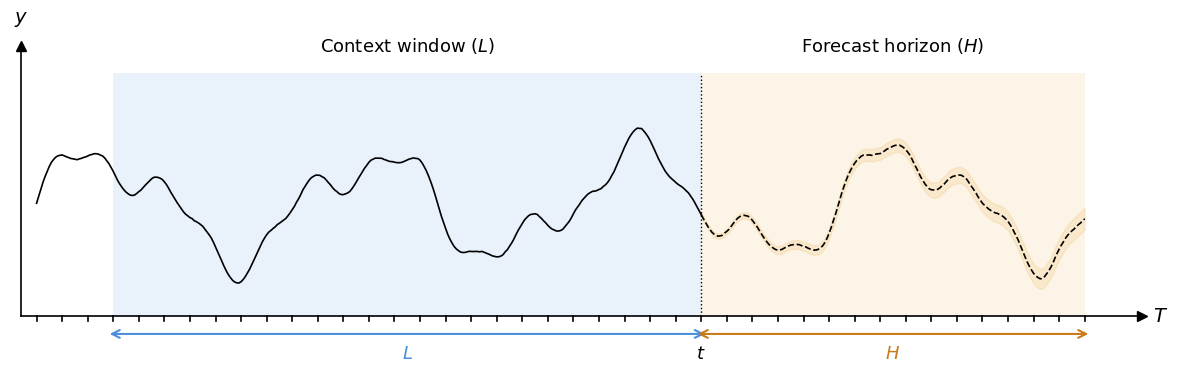

In [57]:
plot_forecast_setup(save=True, save_path=GRAPH_DIR / 'forecast_setup.pdf')

Saved: exploration/figures/DRIFT_Institutions_209.pdf


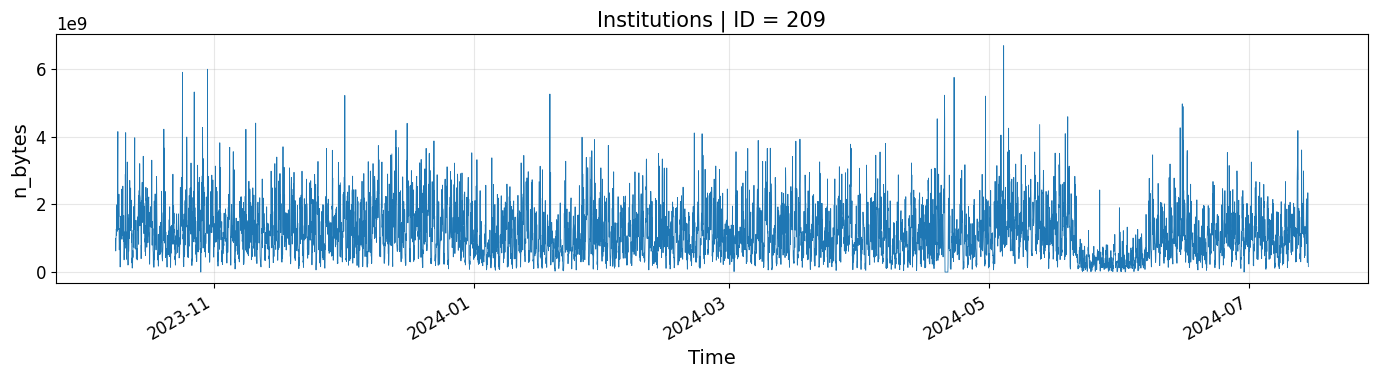

In [8]:
plot_series('DRIFT', 'Institutions', 209, save=True)

## Benchmark-specific graphs

### SEASON — STL Decomposition

In [9]:
from statsmodels.tsa.seasonal import STL
from utils import seasonality_strength


def plot_stl(benchmark, level, ts_id, save=False):
    """STL decomposition panel: observed (log1p), trend, seasonal, residual."""
    d = data_by_level[level]
    grp = d['df'][d['df'][d['id_col']] == ts_id].reset_index(drop=True)
    t = grp['datetime']
    y_log = np.log1p(grp['n_bytes'].astype(float))

    s24 = seasonality_strength(y_log, 24)
    s168 = seasonality_strength(y_log, 168)
    best_period = 24 if s24 >= s168 else 168
    period_label = 'daily (24h)' if best_period == 24 else 'weekly (168h)'

    stl = STL(y_log, period=best_period).fit()

    components = [
        ('Observed — log(1 + n_bytes)', y_log.values, '#1f77b4'),
        ('Trend', stl.trend.values, '#2ca02c'),
        (f'Seasonal (period={period_label})', stl.seasonal.values, '#9467bd'),
        ('Residual', stl.resid.values, '#d62728'),
    ]

    fig, axes = plt.subplots(4, 1, figsize=(16, 11), sharex=True)
    for ax, (title, vals, color) in zip(axes, components):
        ax.plot(t, vals, linewidth=0.5, color=color)
        ax.set_ylabel(title)
        ax.grid(True, alpha=0.3)

    axes[0].set_title(
        f'{level} | ID = {ts_id}  —  seasonal strength: daily={s24:.3f}, weekly={s168:.3f}',
    )
    axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    fig.autofmt_xdate()
    plt.tight_layout()

    if save:
        fname = GRAPH_DIR / f'{benchmark}_STL_{level}_{ts_id}.pdf'
        fig.savefig(fname, bbox_inches='tight')
        print(f'Saved: {fname}')

    plt.show()

Saved: exploration/figures/SEASON_STL_Institutions_15.pdf


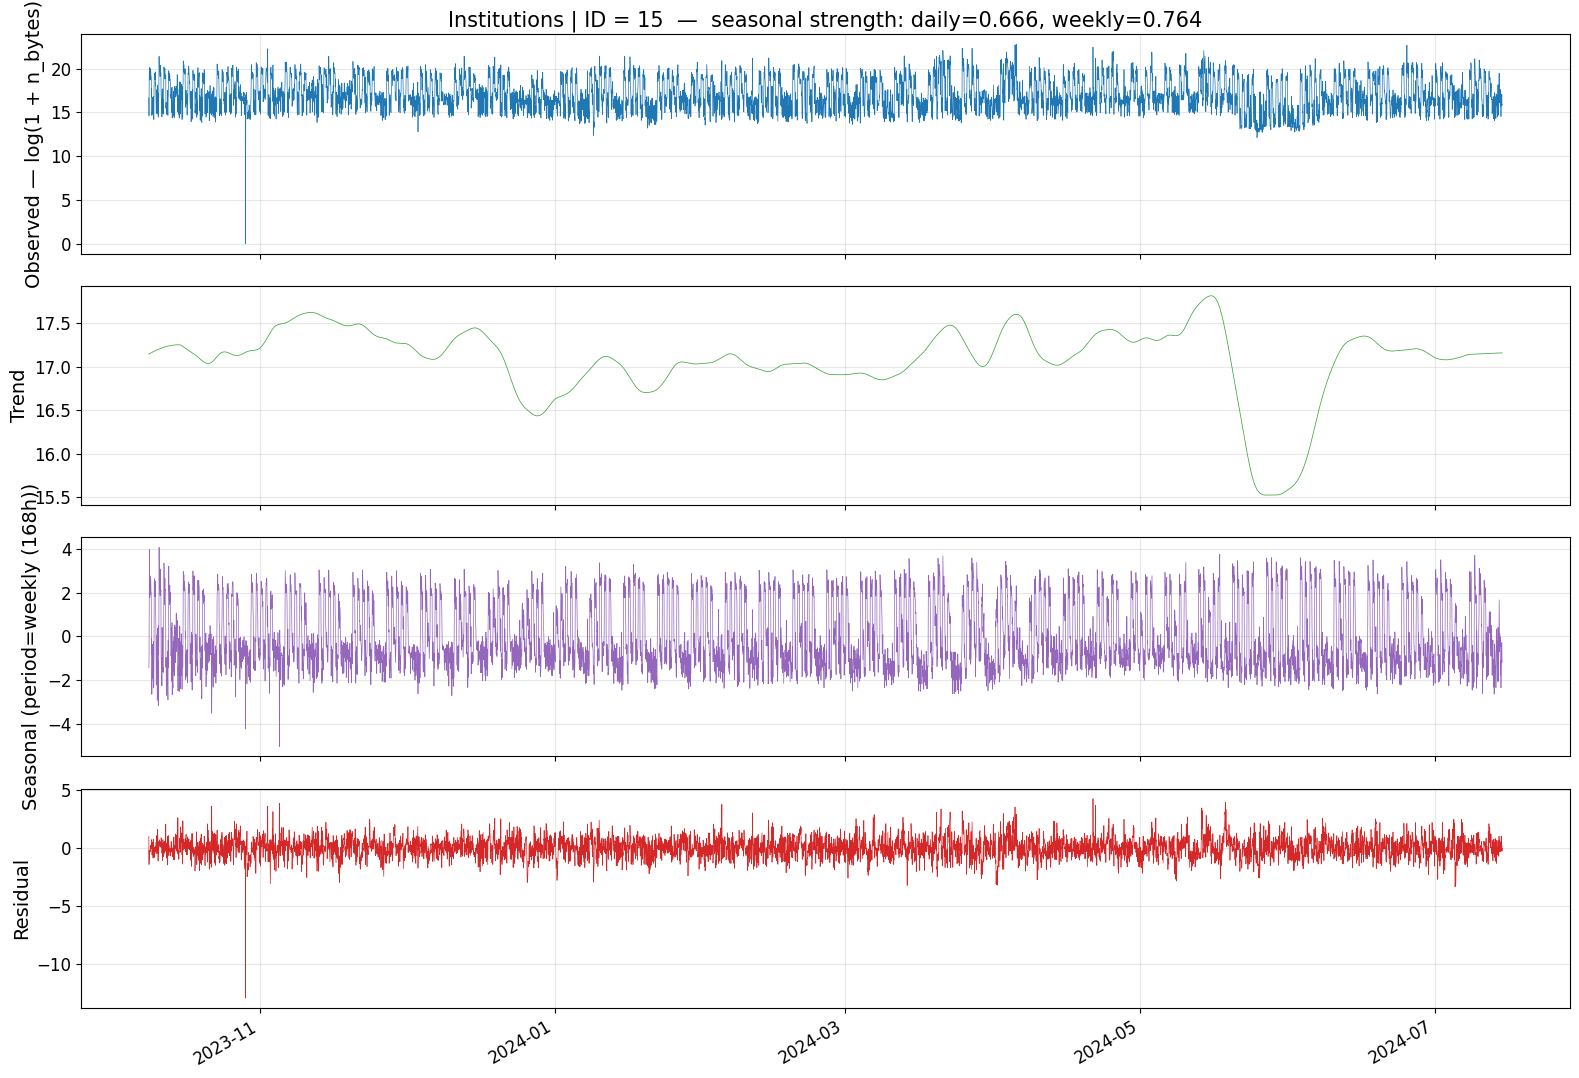

In [10]:
# Example: STL decomposition for first SEASON series
row = selected[selected['benchmark'] == 'SEASON'].iloc[0]
plot_stl('SEASON', row['level'], row['ts_id'], save=True)

### DRIFT — Rolling MA Deviation Pipeline

In [11]:
SHORT_WINDOW = 168       # 1 week
LONG_WINDOW = 744        # ~4 weeks
REL_THRESHOLD = 0.30
MIN_DRIFT_DAYS = 14


def _find_sustained_drift_mask(rel_dev, rel_threshold, min_drift_hours):
    above = (rel_dev > rel_threshold).values
    mask = np.zeros(len(above), dtype=bool)
    i = 0
    while i < len(above):
        if above[i]:
            j = i
            while j < len(above) and above[j]:
                j += 1
            if (j - i) >= min_drift_hours:
                mask[i:j] = True
            i = j
        else:
            i += 1
    return pd.Series(mask, index=rel_dev.index)


def plot_drift(benchmark, level, ts_id, save=False):
    """3-panel drift plot: raw + MAs, relative deviation, drift regions."""
    d = data_by_level[level]
    grp = d['df'][d['df'][d['id_col']] == ts_id].reset_index(drop=True)
    t = grp['datetime']
    y = grp['n_bytes'].astype(float)

    ma_short = y.rolling(window=SHORT_WINDOW, min_periods=SHORT_WINDOW).mean()
    ma_long = y.rolling(window=LONG_WINDOW, min_periods=LONG_WINDOW).mean()

    valid_idx = ma_long.dropna().index
    valid_idx = valid_idx[ma_long.loc[valid_idx] > 0]
    rel_dev = (ma_short.loc[valid_idx] - ma_long.loc[valid_idx]).abs() / ma_long.loc[valid_idx]

    min_drift_hours = MIN_DRIFT_DAYS * 24
    drift_mask = _find_sustained_drift_mask(rel_dev, REL_THRESHOLD, min_drift_hours)

    # Expand to full length for plotting
    rel_full = pd.Series(np.nan, index=y.index)
    rel_full.loc[valid_idx] = rel_dev.values

    sustained_full = pd.Series(False, index=y.index)
    sustained_full.loc[valid_idx] = drift_mask.values

    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

    # Panel 1: raw + MAs
    axes[0].plot(t, y.values, linewidth=0.3, alpha=0.5, label='raw')
    axes[0].plot(t, ma_short.values, linewidth=1, label=f'MA({SHORT_WINDOW}h)', color='orange')
    axes[0].plot(t, ma_long.values, linewidth=1, label=f'MA({LONG_WINDOW}h)', color='green')
    axes[0].set_ylabel('n_bytes')
    axes[0].set_title(f'{level} | ID {ts_id}  —  Raw n_bytes + Moving Averages')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Panel 2: relative deviation
    axes[1].plot(t, rel_full.values * 100, linewidth=0.5)
    axes[1].axhline(REL_THRESHOLD * 100, color='red', linestyle='--', alpha=0.7,
                    label=f'threshold {REL_THRESHOLD*100:.0f}%')
    axes[1].set_ylabel('Relative deviation (%)')
    axes[1].set_title('|MA_short − MA_long| / MA_long')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # Panel 3: drift regions highlighted
    axes[2].plot(t, y.values, linewidth=0.3, alpha=0.5)
    axes[2].fill_between(t, 0, y.max(),
                         where=sustained_full.values, alpha=0.3, color='red',
                         label=f'sustained drift (≥{MIN_DRIFT_DAYS}d)')
    axes[2].set_ylabel('n_bytes')
    axes[2].set_xlabel('Time')
    axes[2].set_title('Drift regions highlighted')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    fig.autofmt_xdate()
    plt.tight_layout()

    if save:
        fname = GRAPH_DIR / f'{benchmark}_pipe_{level}_{ts_id}.pdf'
        fig.savefig(fname, bbox_inches='tight')
        print(f'Saved: {fname}')

    plt.show()

Saved: exploration/figures/DRIFT_pipe_Institutions_209.pdf


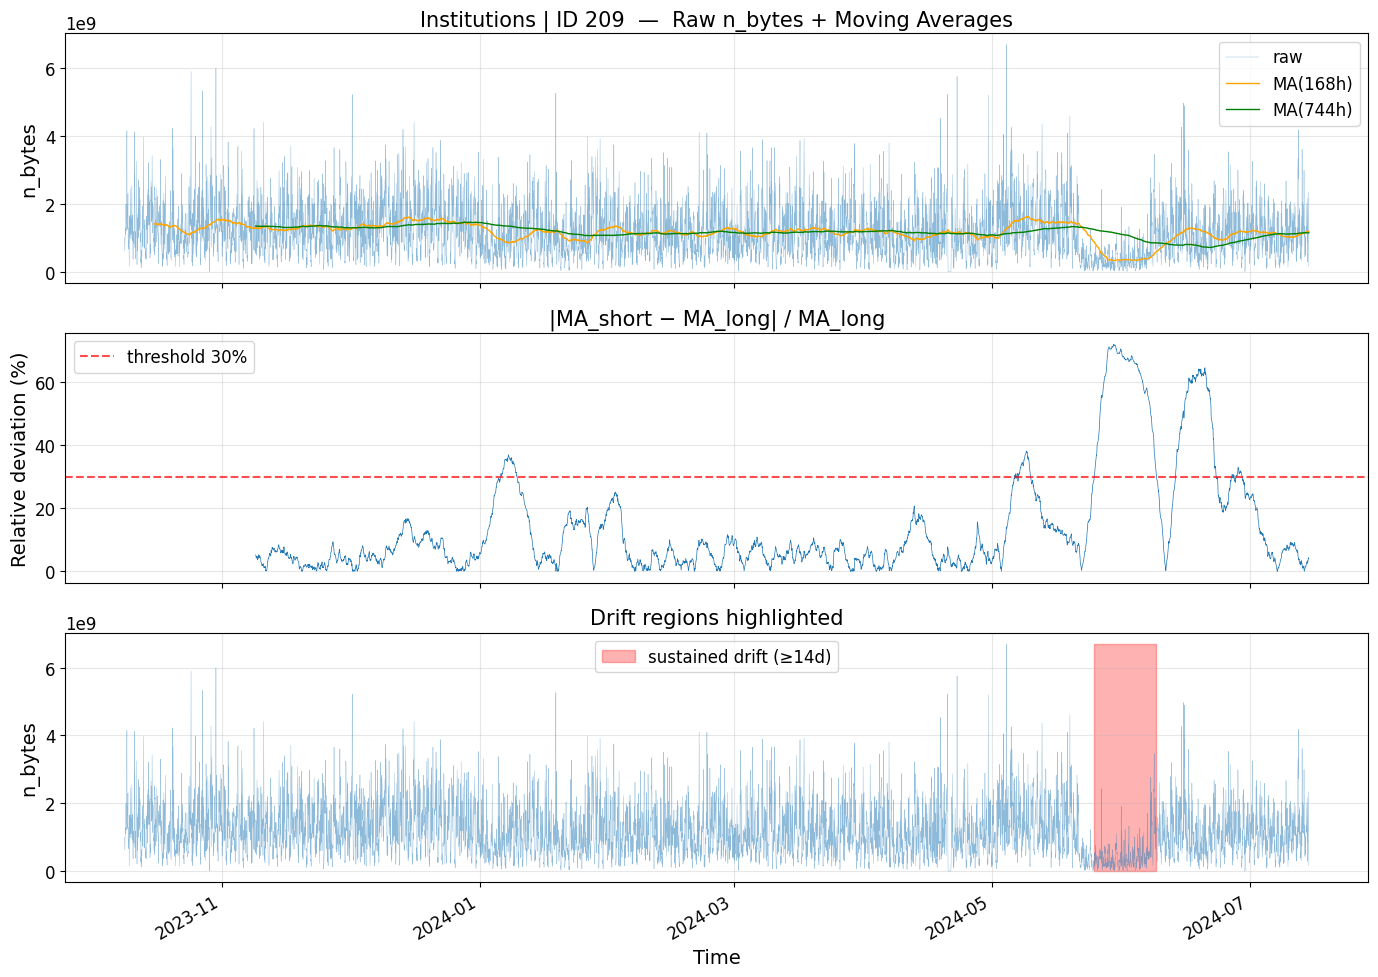

In [12]:
# Example: drift plot for first DRIFT series
row = selected[(selected['benchmark'] == 'DRIFT') & (selected['ts_id'] == 209)].iloc[0]
plot_drift('DRIFT', row['level'], row['ts_id'], save=True)

### PERIODIC SPACES — Binary ACF Correlogram

In [13]:
from statsmodels.tsa.stattools import acf
from scipy.signal import find_peaks

BREAKS_MAX_LAG = 336        # 2 weeks of hourly data
BREAKS_ACF_THRESHOLD = 0.6


def _compute_periodic_score(y, max_lag=BREAKS_MAX_LAG):
    binary = (y == 0).astype(float)
    acf_values = acf(binary, nlags=max_lag, fft=True)
    peaks, _ = find_peaks(acf_values, prominence=0.1)
    if len(peaks) == 0:
        return {"max_acf": 0.0, "dominant_lag": 0, "ratio_zeros": float(binary.mean()), "acf_values": acf_values}
    best = np.argmax(acf_values[peaks])
    return {
        "max_acf": float(acf_values[peaks[best]]),
        "dominant_lag": int(peaks[best]),
        "ratio_zeros": float(binary.mean()),
        "acf_values": acf_values,
    }


def plot_periodic(benchmark, level, ts_id, save=False):
    """3-panel: raw series, binary indicator, ACF correlogram with peaks."""
    d = data_by_level[level]
    grp = d['df'][d['df'][d['id_col']] == ts_id].reset_index(drop=True)
    t = grp['datetime']
    y = grp['n_bytes'].astype(float).values

    result = _compute_periodic_score(y)
    binary = (y == 0).astype(float)
    acf_vals = result['acf_values']

    fig, axes = plt.subplots(3, 1, figsize=(14, 10))

    # Panel 1: raw series (p99 clipped)
    axes[0].plot(t, y, linewidth=0.3, alpha=0.7)
    p99 = np.percentile(y[y > 0], 99) if (y > 0).any() else y.max()
    axes[0].set_ylim(-p99 * 0.03, p99 * 1.1)
    axes[0].set_title(f'{level} | ID {ts_id}  —  Raw n_bytes')
    axes[0].set_ylabel('n_bytes')
    axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    axes[0].grid(True, alpha=0.3)

    # Panel 2: binary indicator
    axes[1].plot(t, binary, linewidth=0.3, color='steelblue')
    axes[1].set_title(r'Binary indicator ($B_t = 1$ if n_bytes = 0, else 0)')
    axes[1].set_ylabel(r'$B_t$')
    axes[1].set_ylim(-0.05, 1.1)
    axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    axes[1].grid(True, alpha=0.3)

    # Panel 3: ACF correlogram (skip lag 0)
    lags = np.arange(1, len(acf_vals))
    axes[2].bar(lags, acf_vals[1:], width=1, alpha=0.7, color='steelblue')
    axes[2].axhline(BREAKS_ACF_THRESHOLD, color='red', linestyle='--', alpha=0.7,
                    label=f'threshold={BREAKS_ACF_THRESHOLD}')
    axes[2].axvline(result['dominant_lag'], color='orange', linestyle='-', alpha=0.8,
                    label=f"dominant lag={result['dominant_lag']}h")
    for d_line in range(1, BREAKS_MAX_LAG // 24 + 1):
        axes[2].axvline(d_line * 24, color='gray', linestyle=':', alpha=0.3)
    axes[2].set_title(
        f"ACF of binary indicator | "
        f"max_acf={result['max_acf']:.3f} at lag={result['dominant_lag']}h | "
        f"zero points={result['ratio_zeros']:.1%}"
    )
    axes[2].set_ylabel('ACF')
    axes[2].set_xlabel('Lag (hours)')
    axes[2].legend()

    fig.autofmt_xdate()
    plt.tight_layout()

    if save:
        fname = GRAPH_DIR / f'{benchmark}_ACF_{level}_{ts_id}.pdf'
        fig.savefig(fname, bbox_inches='tight')
        print(f'Saved: {fname}')

    plt.show()

Saved: exploration/figures/PERIODIC_SPACES_ACF_IPs_722293.pdf


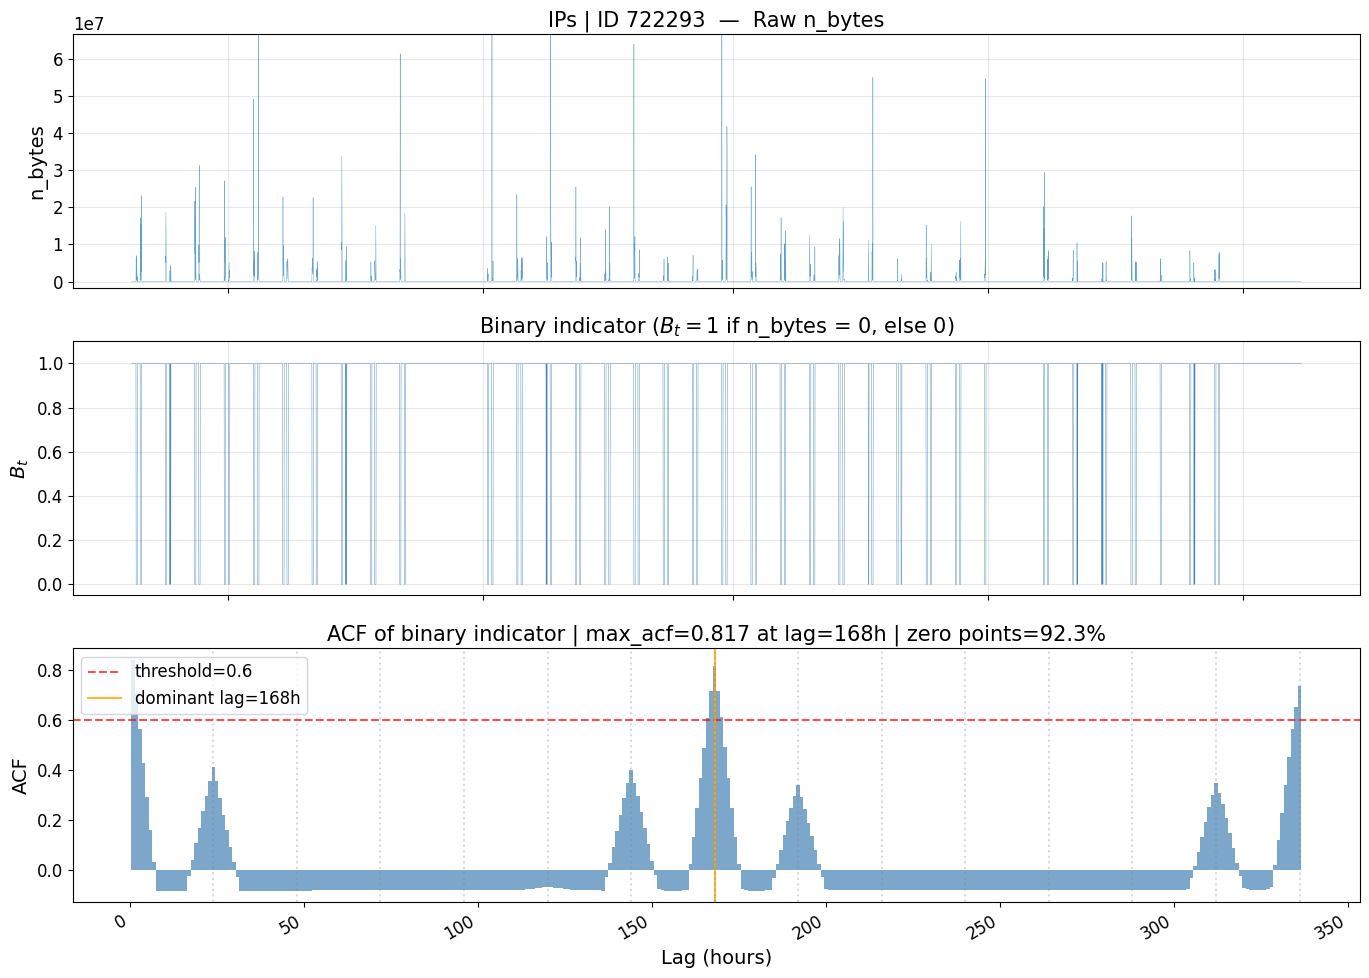

In [14]:
# Example: periodic spaces plot for first PERIODIC_SPACES series
row = selected[(selected['benchmark'] == 'PERIODIC_SPACES') & (selected['ts_id'] == 722293)].iloc[0]
plot_periodic('PERIODIC_SPACES', row['level'], row['ts_id'], save=True)

### WORKERS — Workstation Activity Pattern

In [15]:
# Load weekends & holidays calendar
wh = data_by_level['IPs']['dataset'].get_additional_data("weekends_and_holidays")
wh = wh.copy()
wh["day"] = pd.to_datetime(wh["Date"]).dt.normalize()
non_work_days = set(wh["day"])
print(f"Non-working days in calendar: {len(non_work_days)}")

Non-working days in calendar: 89


In [16]:
def plot_workstation(benchmark, level, ts_id, save=False):
    """2-panel: raw series with weekend/holiday shading + weekly activity heatmap."""
    d = data_by_level[level]
    grp = d['df'][d['df'][d['id_col']] == ts_id].copy().reset_index(drop=True)
    y = grp['n_bytes'].values.astype(float)

    fig, axes = plt.subplots(2, 1, figsize=(14, 8))

    # Panel 1: raw series with non-work-day shading, y clipped at p99
    grp['day'] = grp['datetime'].dt.normalize()
    grp['is_non_work'] = grp['day'].isin(non_work_days)

    axes[0].plot(grp['datetime'].values, y, linewidth=0.3, alpha=0.7)

    p99 = np.percentile(y[y > 0], 99) if (y > 0).any() else y.max()
    axes[0].set_ylim(-p99 * 0.03, p99 * 1.1)

    mask = grp['is_non_work'].values.astype(int)
    changes = np.diff(mask)
    starts = np.where(changes == 1)[0] + 1
    ends = np.where(changes == -1)[0] + 1
    if mask[0] == 1:
        starts = np.r_[0, starts]
    if mask[-1] == 1:
        ends = np.r_[ends, len(mask)]
    for s, e in zip(starts, ends):
        axes[0].axvspan(grp['datetime'].iloc[s], grp['datetime'].iloc[e - 1],
                        alpha=0.1, color='slategray')

    axes[0].set_title(f'{level} | ID {ts_id}  —  Raw n_bytes (shaded = weekends/holidays') #y clipped at p99
    axes[0].set_ylabel('n_bytes')
    axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    axes[0].grid(True, alpha=0.3)

    # Panel 2: weekly activity heatmap
    grp['hour_of_week'] = grp['datetime'].dt.dayofweek * 24 + grp['datetime'].dt.hour
    active_profile = grp.groupby('hour_of_week')['n_bytes'].apply(lambda x: (x > 0).mean())

    heatmap = np.zeros((7, 24))
    for how, val in active_profile.items():
        heatmap[how // 24, how % 24] = val

    im = axes[1].imshow(heatmap, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
    axes[1].set_yticks(range(7))
    axes[1].set_yticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
    axes[1].set_xticks(range(0, 24, 2))
    axes[1].set_xlabel('Hour of day')
    axes[1].set_title('Activity probability by hour-of-week')
    plt.colorbar(im, ax=axes[1], label='P(active)')

    fig.autofmt_xdate()
    plt.tight_layout()

    if save:
        fname = GRAPH_DIR / f'{benchmark}_WORK_{level}_{ts_id}.pdf'
        fig.savefig(fname, bbox_inches='tight')
        print(f'Saved: {fname}')

    plt.show()

Saved: exploration/figures/WORKERS_WORK_IPs_21943.pdf


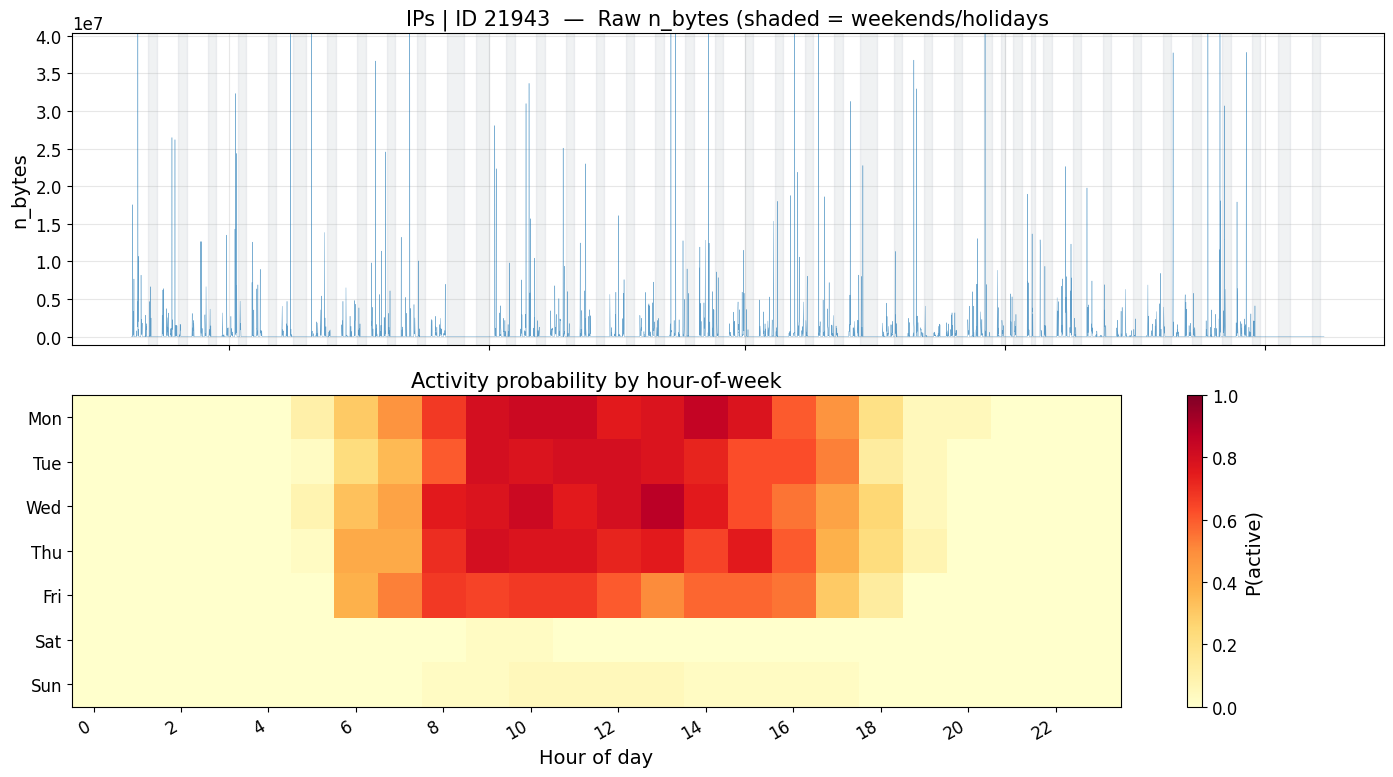

In [17]:
# Example: workstation plot for first WORKERS series
row = selected[(selected['benchmark'] == 'WORKERS') & (selected['ts_id'] == 21943)].iloc[0]
plot_workstation('WORKERS', row['level'], row['ts_id'], save=True)

### RANDOM — ACF White-Noise Verification

In [18]:
RANDOM_MAX_LAG = 168
RANDOM_ACF_THRESHOLD = 0.1


def plot_random(benchmark, level, ts_id, save=False):
    """2-panel: raw series + ACF correlogram with 95% CI band."""
    d = data_by_level[level]
    grp = d['df'][d['df'][d['id_col']] == ts_id].reset_index(drop=True)
    t = grp['datetime']
    y = grp['n_bytes'].astype(float).values

    acf_vals = acf(y, nlags=RANDOM_MAX_LAG, fft=True)
    max_acf = float(np.max(np.abs(acf_vals[1:])))
    n = len(y)
    ci = 1.96 / np.sqrt(n)

    fig, axes = plt.subplots(2, 1, figsize=(14, 8))

    # Panel 1: raw series — clip y-axis at 99th percentile to tame outliers
    axes[0].plot(t, y, linewidth=0.3, alpha=0.7)
    p99 = np.percentile(y[y > 0], 99) if (y > 0).any() else y.max()
    axes[0].set_ylim(-p99 * 0.03, p99 * 1.1)
    axes[0].set_title(f'{level} | ID {ts_id}  —  Raw n_bytes ') #(y clipped at p99)
    axes[0].set_ylabel('n_bytes')
    axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    axes[0].grid(True, alpha=0.3)

    # Panel 2: ACF of raw series (skip lag 0)
    lags = np.arange(1, len(acf_vals))
    axes[1].bar(lags, acf_vals[1:], width=1, alpha=0.7, color='steelblue')
    axes[1].axhline(ci, color='red', linestyle='--', alpha=0.5,
                    label=f'95% CI ({chr(177)}{ci:.3f})')
    axes[1].axhline(-ci, color='red', linestyle='--', alpha=0.5)
    axes[1].axhline(RANDOM_ACF_THRESHOLD, color='orange', linestyle=':', alpha=0.7,
                    label=f'threshold={RANDOM_ACF_THRESHOLD}')
    axes[1].axhline(-RANDOM_ACF_THRESHOLD, color='orange', linestyle=':', alpha=0.7)
    axes[1].set_title(f'ACF of n_bytes | max |ACF|={max_acf:.3f}')
    axes[1].set_ylabel('ACF')
    axes[1].set_xlabel('Lag (hours)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    fig.autofmt_xdate()
    plt.tight_layout()

    if save:
        fname = GRAPH_DIR / f'{benchmark}_ACF_{level}_{ts_id}.pdf'
        fig.savefig(fname, bbox_inches='tight')
        print(f'Saved: {fname}')

    plt.show()

Saved: exploration/figures/RANDOM_ACF_Subnets_89.pdf


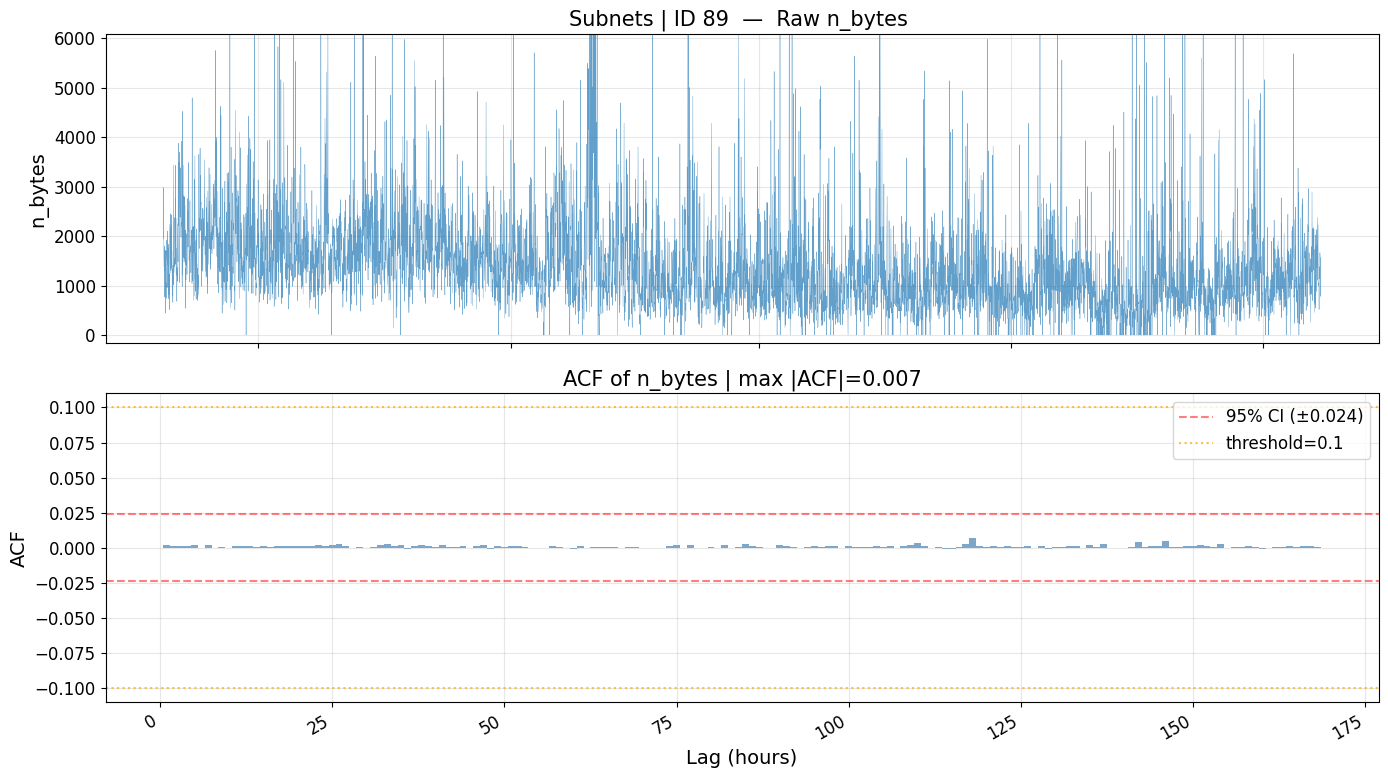

In [19]:
# Example: random plot for first RANDOM series
row = selected[(selected['benchmark'] == 'RANDOM') & (selected['ts_id'] == 89) & (selected['level'] == 'Subnets')].iloc[0]
plot_random('RANDOM', row['level'], row['ts_id'], save=True)